In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
np.random.seed(0)

Using device: mps


In [8]:
dataset_path = "veg_subset"
print("Classes found:", sorted(os.listdir(dataset_path)))

Classes found: ['Bean', 'Garlic', 'Green Chili', 'Onion', 'Potato', 'Radish']


In [9]:
IMG_SIZE = 128
BATCH_SIZE = 32

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_ds = datasets.ImageFolder(dataset_path, transform=basic_transform)
class_names = full_ds.classes
print("Classes:", class_names)
print("Total images:", len(full_ds))

n_train = int(0.8 * len(full_ds))
n_val = len(full_ds) - n_train
train_idx, val_idx = random_split(range(len(full_ds)), [n_train, n_val],
                                   generator=torch.Generator().manual_seed(0))

train_ds = Subset(full_ds, train_idx.indices)
val_ds = Subset(full_ds, val_idx.indices)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train images:", len(train_ds))
print("Val images  :", len(val_ds))

Classes: ['Bean', 'Garlic', 'Green Chili', 'Onion', 'Potato', 'Radish']
Total images: 2332
Train images: 1865
Val images  : 467


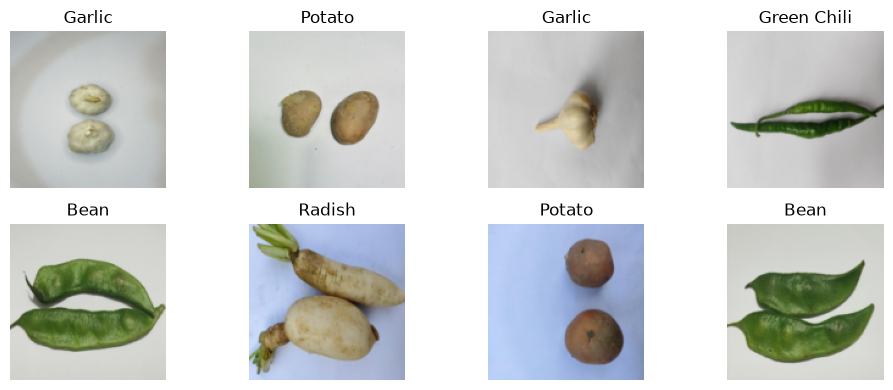

In [10]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes, p_dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p_dropout)
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=len(class_names), p_dropout=0.0).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params:,}")

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)
Total trainable parameters: 2,121,638


In [12]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs}  "
              f"train_loss={train_loss:.3f} train_acc={train_acc:.3f}  |  "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

    return history

history_plain = train_model(model, train_loader, val_loader, epochs=15)

Epoch  1/15  train_loss=1.347 train_acc=0.469  |  val_loss=0.630 val_acc=0.786
Epoch  2/15  train_loss=0.386 train_acc=0.861  |  val_loss=0.289 val_acc=0.869
Epoch  3/15  train_loss=0.209 train_acc=0.931  |  val_loss=0.191 val_acc=0.927
Epoch  4/15  train_loss=0.094 train_acc=0.970  |  val_loss=0.093 val_acc=0.976
Epoch  5/15  train_loss=0.055 train_acc=0.983  |  val_loss=0.096 val_acc=0.964
Epoch  6/15  train_loss=0.049 train_acc=0.986  |  val_loss=0.063 val_acc=0.989
Epoch  7/15  train_loss=0.028 train_acc=0.992  |  val_loss=0.080 val_acc=0.972
Epoch  8/15  train_loss=0.015 train_acc=0.996  |  val_loss=0.033 val_acc=0.989
Epoch  9/15  train_loss=0.010 train_acc=0.997  |  val_loss=0.034 val_acc=0.987
Epoch 10/15  train_loss=0.003 train_acc=1.000  |  val_loss=0.039 val_acc=0.994
Epoch 11/15  train_loss=0.002 train_acc=0.999  |  val_loss=0.029 val_acc=0.989
Epoch 12/15  train_loss=0.007 train_acc=0.998  |  val_loss=0.074 val_acc=0.979
Epoch 13/15  train_loss=0.003 train_acc=0.999  |  va

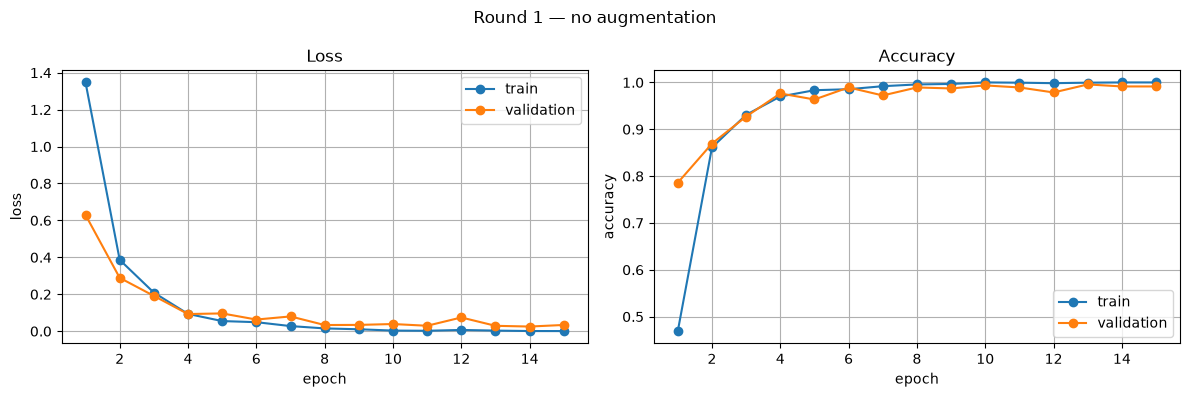

In [13]:
def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], "o-", label="train")
    ax1.plot(epochs, history["val_loss"], "o-", label="validation")
    ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], "o-", label="train")
    ax2.plot(epochs, history["val_acc"], "o-", label="validation")
    ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
    ax2.legend(); ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_plain, "Round 1 — no augmentation")

Augmented training pipeline ready.
Epoch  1/15  train_loss=1.270 train_acc=0.492  |  val_loss=0.782 val_acc=0.713
Epoch  2/15  train_loss=0.500 train_acc=0.818  |  val_loss=0.347 val_acc=0.863
Epoch  3/15  train_loss=0.272 train_acc=0.900  |  val_loss=0.188 val_acc=0.931
Epoch  4/15  train_loss=0.166 train_acc=0.944  |  val_loss=0.083 val_acc=0.985
Epoch  5/15  train_loss=0.126 train_acc=0.957  |  val_loss=0.127 val_acc=0.955
Epoch  6/15  train_loss=0.123 train_acc=0.961  |  val_loss=0.077 val_acc=0.976
Epoch  7/15  train_loss=0.115 train_acc=0.957  |  val_loss=0.042 val_acc=0.991
Epoch  8/15  train_loss=0.078 train_acc=0.972  |  val_loss=0.058 val_acc=0.981
Epoch  9/15  train_loss=0.101 train_acc=0.964  |  val_loss=0.136 val_acc=0.964
Epoch 10/15  train_loss=0.075 train_acc=0.977  |  val_loss=0.052 val_acc=0.979
Epoch 11/15  train_loss=0.039 train_acc=0.986  |  val_loss=0.055 val_acc=0.985
Epoch 12/15  train_loss=0.035 train_acc=0.988  |  val_loss=0.031 val_acc=0.994
Epoch 13/15  trai

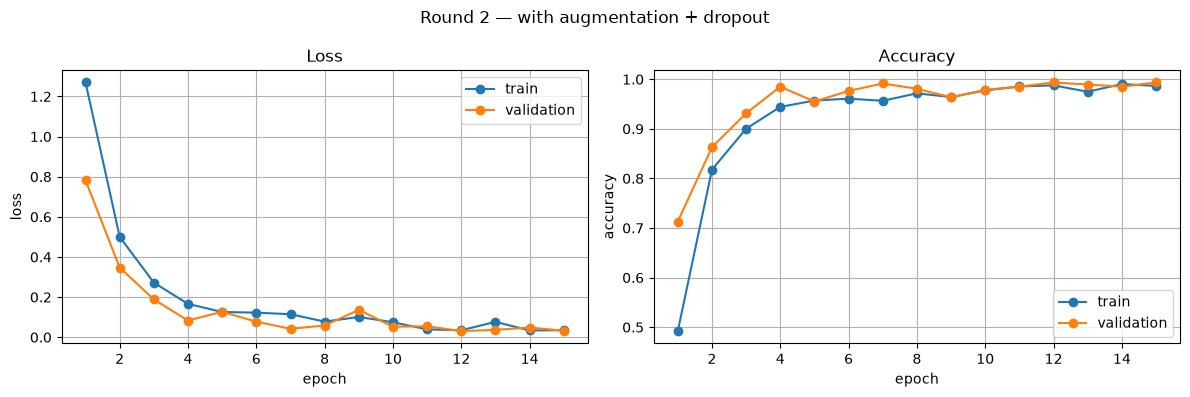

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_ds_aug = datasets.ImageFolder(dataset_path, transform=train_transform)
full_ds_clean = datasets.ImageFolder(dataset_path, transform=val_transform)

train_ds_aug = Subset(full_ds_aug, train_idx.indices)
val_ds_clean = Subset(full_ds_clean, val_idx.indices)

train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_clean = DataLoader(val_ds_clean, batch_size=BATCH_SIZE, shuffle=False)

print("Augmented training pipeline ready.")

model_aug = SimpleCNN(num_classes=len(class_names), p_dropout=0.5).to(device)
history_aug = train_model(model_aug, train_loader_aug, val_loader_clean, epochs=15)
plot_history(history_aug, "Round 2 — with augmentation + dropout")

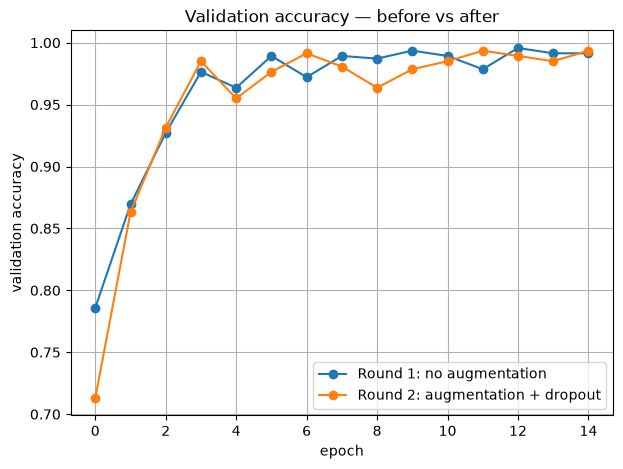

Best val acc (Round 1): 0.996
Best val acc (Round 2): 0.994


In [15]:
plt.figure(figsize=(7, 5))
plt.plot(history_plain["val_acc"], "o-", label="Round 1: no augmentation")
plt.plot(history_aug["val_acc"], "o-", label="Round 2: augmentation + dropout")
plt.title("Validation accuracy — before vs after")
plt.xlabel("epoch"); plt.ylabel("validation accuracy")
plt.legend(); plt.grid(True)
plt.show()

print(f"Best val acc (Round 1): {max(history_plain['val_acc']):.3f}")
print(f"Best val acc (Round 2): {max(history_aug['val_acc']):.3f}")

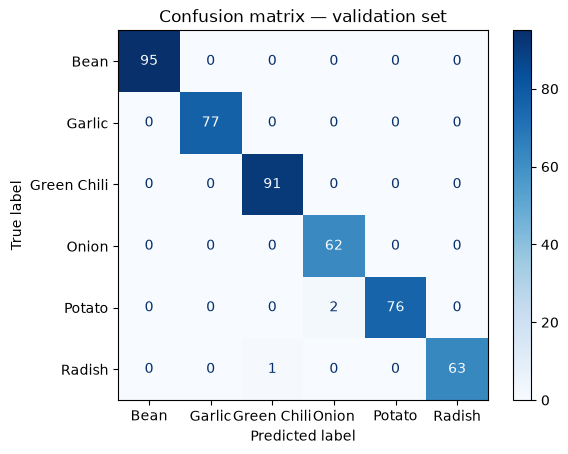

              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00        95
      Garlic       1.00      1.00      1.00        77
 Green Chili       0.99      1.00      0.99        91
       Onion       0.97      1.00      0.98        62
      Potato       1.00      0.97      0.99        78
      Radish       1.00      0.98      0.99        64

    accuracy                           0.99       467
   macro avg       0.99      0.99      0.99       467
weighted avg       0.99      0.99      0.99       467



In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            preds.append(outputs.argmax(1).cpu())
            targets.append(labels)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

y_pred, y_true = get_predictions(model_aug, val_loader_clean)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix — validation set")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))